## Import Theme

In [2]:
import importlib
import sys
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import theme
import altair as alt
import plotly.graph_objects as go
from plotly.subplots import make_subplots
theme.activate_all()
from theme import activate_all, CONF_COLORS, TEXT_PRIMARY, TEXT_SECONDARY, BACKGROUND, format_title, add_signature
from theme import register_plotly_theme, NAVY, GOLD, RED, TEXT_PRIMARY, TEXT_SECONDARY, BACKGROUND

register_plotly_theme()



BDT theme activated


In [3]:
master = pd.read_csv("data/master.csv")
complete = master[master["complete_window"] == True].copy()

## Aggregations

In [4]:
program_level = (complete.groupby("team")
                 .agg(
                     avg_rec_points=("rec_points", "mean"),
                     avg_win_pct=("win_pct", "mean"),
                     avg_dev_residual=("development_residual", "mean"),
                     seasons=("year", "count")
                 )
                 .query("seasons >= 5")
                 .reset_index())

# conference
conf_mode = (complete.groupby("team")["conference"]
             .agg(lambda x: x.dropna().mode().iloc[0]
                  if len(x.dropna()) > 0 else "Unknown"))
program_level = program_level.merge(
    conf_mode.reset_index(),
    on="team", how="left"
)

# filter to fbs conferences only
fbs_conferences = [
    "SEC", "Big Ten", "ACC", "Big 12", "Pac-12",
    "Mountain West", "American Athletic", "Conference USA",
    "Mid-American", "Sun Belt", "FBS Independents"
]
program_level = program_level[
    program_level["conference"].isin(fbs_conferences)
].copy()

print(program_level.shape)
print(program_level["conference"].value_counts())

(128, 6)
conference
Big Ten              18
ACC                  17
SEC                  16
Big 12               16
American Athletic    14
Mid-American         12
Sun Belt             11
Mountain West         9
Pac-12                8
Conference USA        5
FBS Independents      2
Name: count, dtype: int64


## First Static Visualization

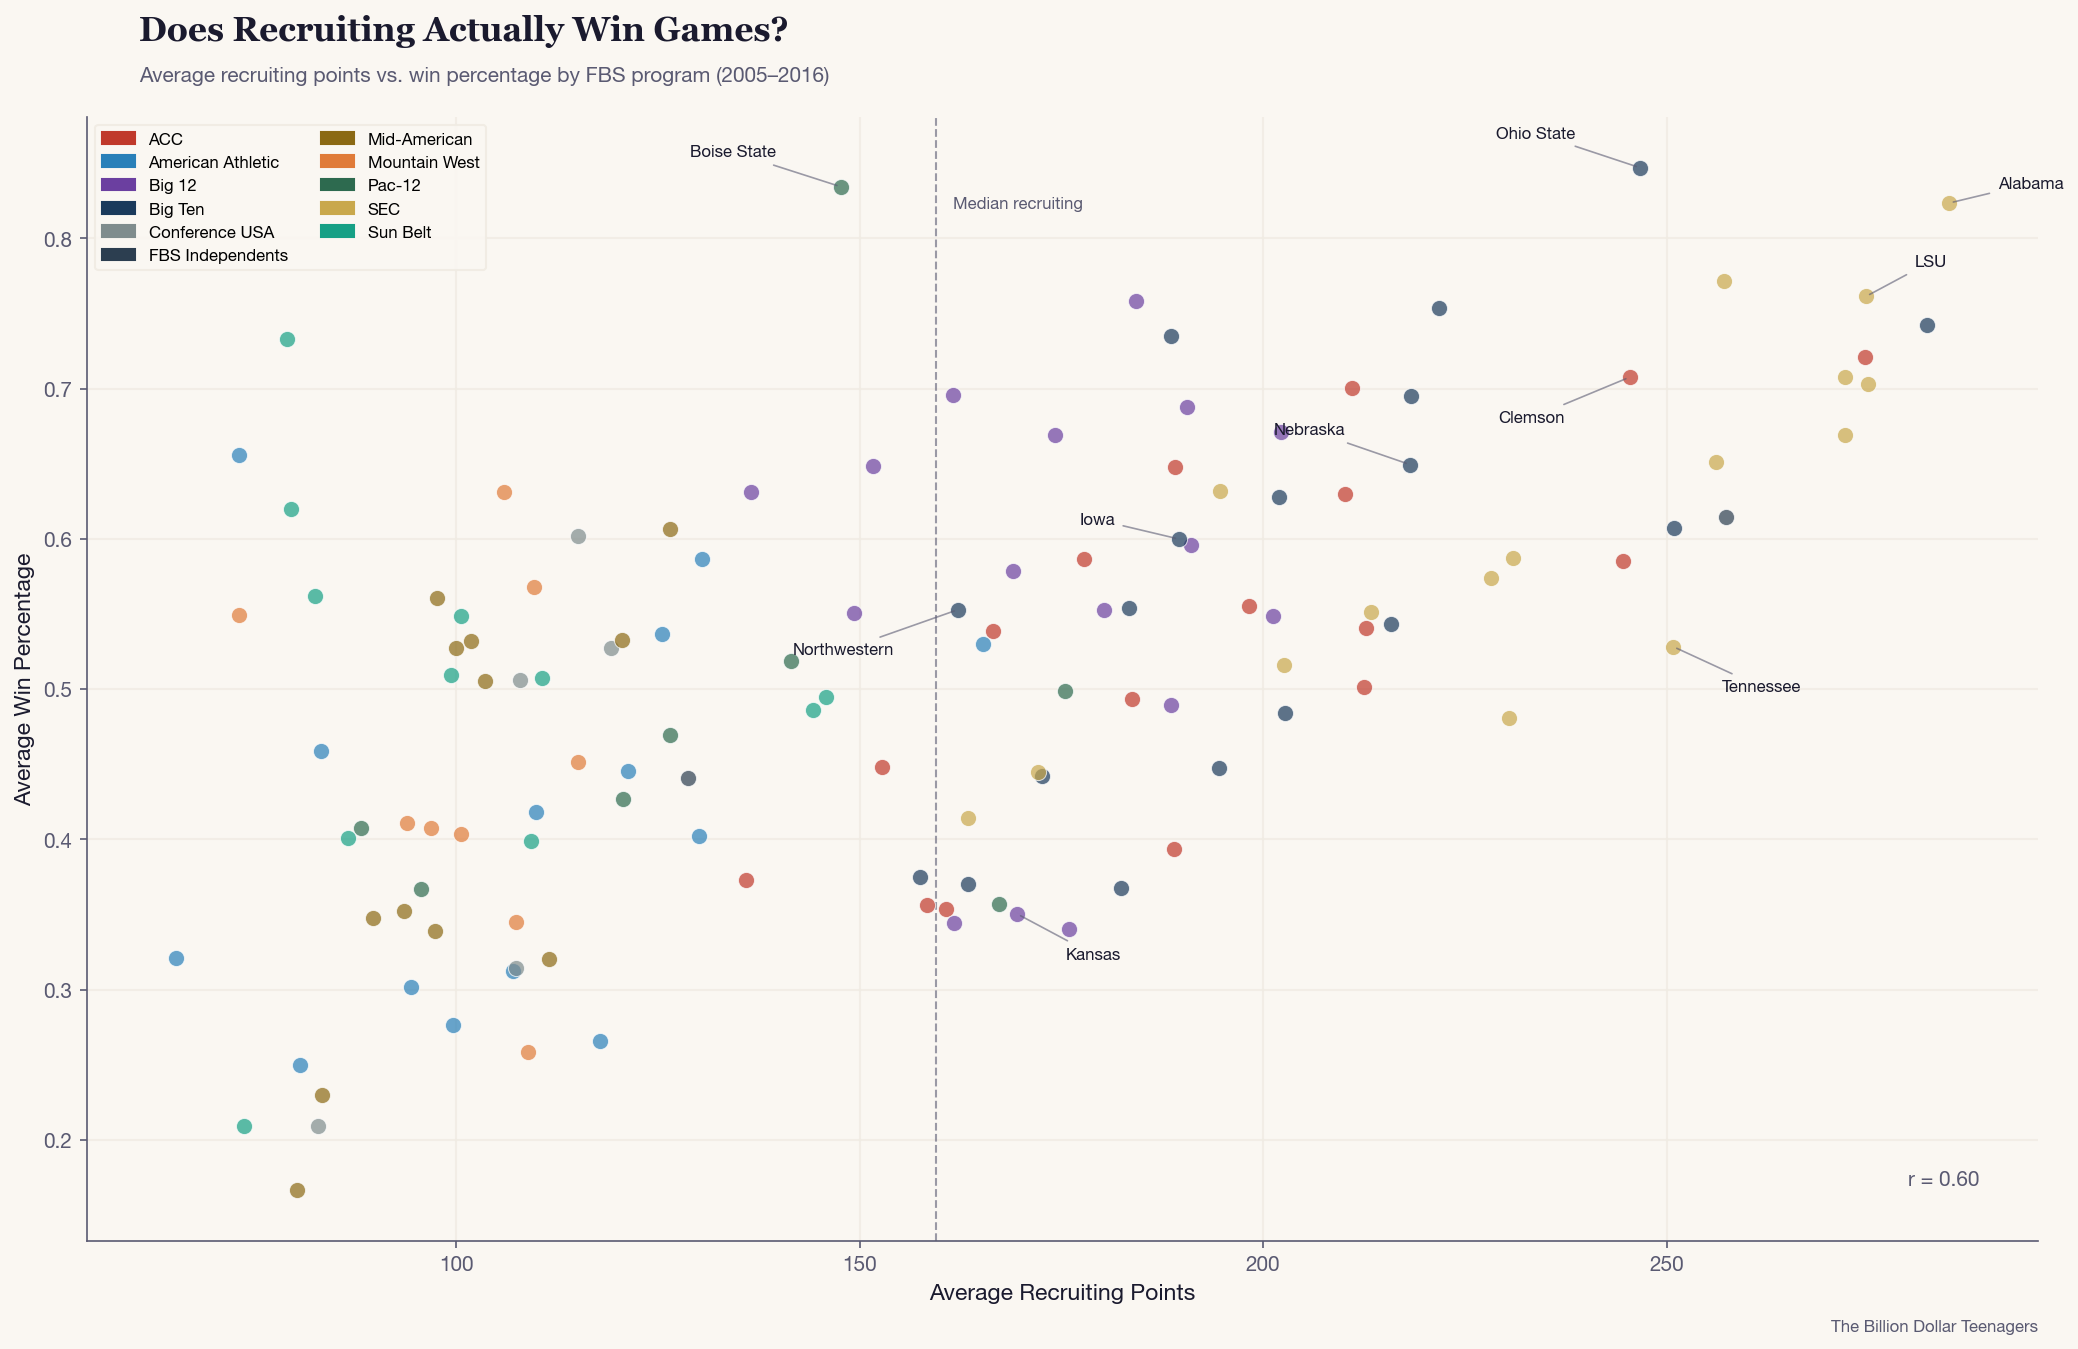

In [7]:
fig, ax = plt.subplots(figsize=(14, 9))
fig.patch.set_facecolor(BACKGROUND)

for conf, group in program_level.groupby("conference"):
    color = CONF_COLORS.get(conf, "#9B9B9B")
    ax.scatter(group["avg_rec_points"], group["avg_win_pct"],
               color=color, alpha=0.7, s=60, zorder=3,
               edgecolors="white", linewidths=0.5)

# Median line
median_rec = program_level["avg_rec_points"].median()
ax.axvline(x=median_rec, color=TEXT_SECONDARY, linestyle="--",
           linewidth=1, alpha=0.6, zorder=2)
ax.text(median_rec + 2, 0.82, "Median recruiting",
        fontsize=8, color=TEXT_SECONDARY, style="italic")

# labels for some key programs
label_configs = {
    "Alabama":      (6,   0.01,  "left"),
    "Ohio State":   (-8,  0.02,  "right"),
    "Iowa":         (-8,  0.01,  "right"),
    "Tennessee":    (6,  -0.03,  "left"),
    "Nebraska":     (-8,  0.02,  "right"),
    "Clemson":      (-8, -0.03,  "right"),
    "Kansas":       (6,  -0.03,  "left"),
    "Boise State":  (-8,  0.02,  "right"),
    "LSU":          (6,   0.02,  "left"),
    "Northwestern": (-8, -0.03,  "right"),
}

for team, (ox, oy, ha) in label_configs.items():
    row = program_level[program_level["team"] == team]
    if len(row) == 0:
        continue
    x = row["avg_rec_points"].values[0]
    y = row["avg_win_pct"].values[0]
    ax.annotate(
        team,
        xy=(x, y),
        xytext=(x + ox, y + oy),
        fontsize=8,
        color=TEXT_PRIMARY,
        ha=ha,
        arrowprops=dict(arrowstyle="-", color=TEXT_SECONDARY,
                        lw=0.8, alpha=0.6),
        zorder=5
    )

# correlation
corr = program_level[["avg_rec_points", "avg_win_pct"]].corr().iloc[0, 1]
ax.text(0.97, 0.05, f"r = {corr:.2f}",
        transform=ax.transAxes, ha="right",
        fontsize=10, color=TEXT_SECONDARY, style="italic")

# legend
plotted_confs = program_level["conference"].unique()
legend_patches = [
    mpatches.Patch(color=CONF_COLORS.get(conf, "#9B9B9B"), label=conf)
    for conf in sorted(CONF_COLORS.keys())
    if conf in plotted_confs
]
ax.legend(handles=legend_patches, loc="upper left",
          fontsize=8, ncol=2, framealpha=0.9)

# title
ax.set_title("")
fig.text(0.07, 0.97, "Does Recruiting Actually Win Games?",
         fontsize=16, fontweight="bold", color=TEXT_PRIMARY,
         fontfamily="Georgia")
fig.text(0.07, 0.94, "Average recruiting points vs. win percentage by FBS program (2005–2016)",
         fontsize=10, color=TEXT_SECONDARY)

ax.set_xlabel("Average Recruiting Points", fontsize=11)
ax.set_ylabel("Average Win Percentage", fontsize=11)
add_signature(ax)

plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.show()

Explanation for r=.61: At the program level, recruiting explains about 37% of winning variance (R^2 = .61^2). However, this overstates recruiting's predictive power. At the season level, where year to year fluctations are captured, the relationship drops as recruiting explains only 16% of winning variance at the season level (r=.40). 

Main takeways
- Relationship exists but is weaker than expected. There's a weak positive trend of programs recruiting better generally winning more. But the scatter is enormous. 
- The overperformers: Boise state is the standout, but Iowa and Northwestern show similar trends. Winning without elite recruiting, something else is driving their success
- Below the median, recruiting rank is essentially useless. Win percentage ranges from .17 to .73, there is virtually no relationship at all for programs recruiting below the median

This is consistent with college football ideas that team that recruit better win more. However, this is just an average across 11 seasons. When you look at the season by season trajectory, recruiting takes a back seat role compared to player development (will go into this in next few visualizations)

Point out that it's clear that there are some programs who recruit weakly but win a lot and some programs who recruit strong athletes but lose a lot

## Interactive 4

Trajectory Explorer. Reader exploration tool after the guided case studies. this is the "find your own team"

In [8]:
from theme import register_plotly_theme, NAVY, GOLD, RED, TEXT_PRIMARY, TEXT_SECONDARY, BACKGROUND

register_plotly_theme()

program_yearly = (complete.groupby(["team", "year"])
                  .agg(
                      win_pct=("win_pct", "mean"),
                      rec_rank=("rec_rank", "mean"),
                      dev_residual=("development_residual", "mean"),
                  )
                  .reset_index())

# filter to only allow teams with all years covered
required_years = set(range(2005, 2017))

valid_teams = []
for team, group in program_yearly.groupby("team"):
    team_years = set(group["year"].unique())
    if required_years.issubset(team_years):
        valid_teams.append(team)

print(f"Teams with complete 2005-2016 data: {len(valid_teams)}")

program_yearly = program_yearly[
    program_yearly["team"].isin(valid_teams)
].copy()

teams = sorted(valid_teams)

def build_traces(data):
    d = data.copy().sort_values("year")
    return d

# make default Alabama
default_data = program_yearly[program_yearly["team"] == "Alabama"]
d = build_traces(default_data)

fig = make_subplots(
    rows=3, cols=1,
    shared_xaxes=True,
    subplot_titles=(
        "Win Percentage",
        "Recruiting Class Rank (lower number = better class)",
        "Development Residual (NFL draft production vs expectations)"
    ),
    vertical_spacing=0.10
)

fig.add_trace(go.Scatter(
    x=d["year"], y=d["win_pct"],
    mode="lines+markers",
    name="Win %",
    line=dict(color=NAVY, width=2.5),
    marker=dict(size=6),
    hovertemplate="Year: %{x}<br>Win %%: %{y:.3f}<extra></extra>"
), row=1, col=1)

fig.add_trace(go.Scatter(
    x=d["year"], y=d["rec_rank"],
    mode="lines+markers",
    name="Recruiting",
    line=dict(color=GOLD, width=2.5),
    marker=dict(size=6),
    hovertemplate="Year: %{x}<br>Recruiting rank: #%{y:.0f}<extra></extra>"
), row=2, col=1)

fig.add_trace(go.Scatter(
    x=d["year"], y=d["dev_residual"],
    mode="lines+markers",
    name="Development",
    line=dict(color=RED, width=2.5),
    marker=dict(size=6),
    hovertemplate="Year: %{x}<br>Dev residual: %{y:.1f}<extra></extra>"
), row=3, col=1)

# zero line on development panel
fig.add_hline(y=0, line_dash="dash",
              line_color=TEXT_SECONDARY,
              line_width=1, opacity=0.5, row=3, col=1)

# invert recruiting rank axis so rank 1 is at the top
fig.update_yaxes(autorange="reversed", row=2, col=1)

# team dropdown
team_buttons = []
for team in teams:
    data = program_yearly[program_yearly["team"] == team].sort_values("year")
    d = build_traces(data)
    team_buttons.append(dict(
        label=team,
        method="update",
        args=[
            {
                "x": [d["year"], d["year"], d["year"]],
                "y": [d["win_pct"],
                      d["rec_rank"],
                      d["dev_residual"]],
            },
            {"title.text": f"<b>{team}</b>: Recruiting, Winning & Development Over Time"}
        ]
    ))

fig.update_layout(
    title=dict(
        text="<b>Alabama</b>: Recruiting, Winning & Development Over Time",
        x=0.05,
        xanchor="left",
        y=0.98
    ),
    height=700,
    width=950,
    showlegend=False,
    margin=dict(t=120, r=60, b=60, l=70),
    paper_bgcolor=BACKGROUND,
    plot_bgcolor=BACKGROUND,
    updatemenus=[dict(
        buttons=team_buttons,
        direction="down",
        showactive=True,
        x=0.01,
        xanchor="left",
        y=1.08,
        yanchor="top",
        bgcolor=BACKGROUND,
        bordercolor=TEXT_SECONDARY,
        font=dict(size=11, color=TEXT_PRIMARY),
    )],
    annotations=[
        dict(
            text="Select Team:",
            x=0.01, y=1.13,
            xref="paper", yref="paper",
            showarrow=False,
            font=dict(size=11, color=TEXT_PRIMARY)
        )
    ]
)

fig.update_xaxes(
    tickmode="linear", dtick=1,
    tickfont=dict(size=9),
    row=3, col=1
)

fig.update_yaxes(title_text="Win %", row=1, col=1)
fig.update_yaxes(title_text="Recruiting Rank", row=2, col=1)
fig.update_yaxes(title_text="Dev Residual", row=3, col=1)

fig.show()

Teams with complete 2005-2016 data: 114


## Interactive 3

Lag correlation chart

In [10]:

from theme import register_plotly_theme, NAVY, RED, GOLD, GREEN, TEXT_PRIMARY, TEXT_SECONDARY, BACKGROUND

register_plotly_theme()

# recompute lag correlations
results = []

for team, group in complete.groupby("team"):
    group = group.sort_values("year").reset_index(drop=True)
    if len(group) < 7:
        continue
    for lag in [1, 2, 3]:
        results.append({
            "team": team,
            "lag": lag,
            "rec_leads_win":   group["rec_points"].corr(group["win_pct"].shift(-lag)),
            "draft_leads_win": group["draft_score_total"].corr(group["win_pct"].shift(-lag)),
            "dev_leads_win":   group["development_residual"].corr(group["win_pct"].shift(-lag)),
        })

lag_df = pd.DataFrame(results)

avg_lags = (lag_df.groupby("lag")
            [["rec_leads_win", "draft_leads_win", "dev_leads_win"]]
            .mean().round(3).reset_index())

labels = ["Recruiting", "Draft Production", "Development"]
cols = ["rec_leads_win", "draft_leads_win", "dev_leads_win"]
colors = [GOLD, GREEN, RED]

fig = go.Figure()

for lag in [1, 2, 3]:
    lag_data = avg_lags[avg_lags["lag"] == lag].iloc[0]
    values = [lag_data[col] for col in cols]

    fig.add_trace(go.Bar(
        x=labels,
        y=values,
        name=f"Lag {lag}",
        visible=(lag == 1),
        marker=dict(color=colors, opacity=0.85),
        text=[f"r = {v:.3f}" for v in values],
        textposition="outside",
        textfont=dict(size=12, color=TEXT_PRIMARY),
        hovertemplate=(
            "<b>%{x}</b><br>"
            f"Correlation {lag} year(s) later: %{{y:.3f}}<br>"
            "<extra></extra>"
        )
    ))

fig.add_hline(y=0, line_color=TEXT_PRIMARY,
              line_width=0.8, opacity=0.5)

lag_buttons = []
for i, lag in enumerate([1, 2, 3]):
    visible = [j == i for j in range(3)]
    lag_buttons.append(dict(
        label=f"{lag} Year{'s' if lag > 1 else ''} Later",
        method="update",
        args=[
            {"visible": visible},
            {"title.text": (
                f"<b>What Predicts Winning {lag} Year{'s' if lag > 1 else ''} From Now?</b><br>"
                f"<sup>Draft production and development predict future wins. "
                f"Recruiting predicts almost nothing {lag} year(s) out.</sup>"
            )}
        ]
    ))

fig.update_layout(
    title=dict(
        text="<b>What Predicts Winning 1 Year From Now?</b><br>"
             "<sup>Draft production and development predict future wins. Recruiting predicts almost nothing.</sup>",
        x=0.05,
        xanchor="left"
    ),
    xaxis=dict(
        tickfont=dict(size=13, color=TEXT_PRIMARY),
    ),
    yaxis=dict(
        title="Correlation with Future Winning",
        range=[-0.05, 0.45],
        zeroline=False,
    ),
    updatemenus=[dict(
        type="buttons",
        direction="left",
        buttons=lag_buttons,
        pad={"r": 10, "t": 10},
        showactive=True,
        x=0.01,
        xanchor="left",
        y=1.12,
        yanchor="top",
        bgcolor=BACKGROUND,
        bordercolor=TEXT_SECONDARY,
        font=dict(size=11, color=TEXT_PRIMARY)
    )],
    annotations=[
        dict(
            text="",
            x=0.01, y=1.17,
            xref="paper", yref="paper",
            showarrow=False,
            font=dict(size=11, color=TEXT_PRIMARY)
        )
    ],
    showlegend=False,
    height=500,
    width=900,
    margin=dict(t=130, r=60, b=60, l=60),
    paper_bgcolor=BACKGROUND,
    plot_bgcolor=BACKGROUND,
)

fig.show()
fig.write_html("assets/lag_interactive.html")

/opt/miniconda3/lib/python3.13/site-packages/numpy/lib/_function_base_impl.py:3065: RuntimeWarning:

invalid value encountered in divide

/opt/miniconda3/lib/python3.13/site-packages/numpy/lib/_function_base_impl.py:3066: RuntimeWarning:

invalid value encountered in divide



Development and draft production are a predictive signal that the program is in the right direction

## Static 2: Alabama vs Tennessee Case study

BDT theme activated


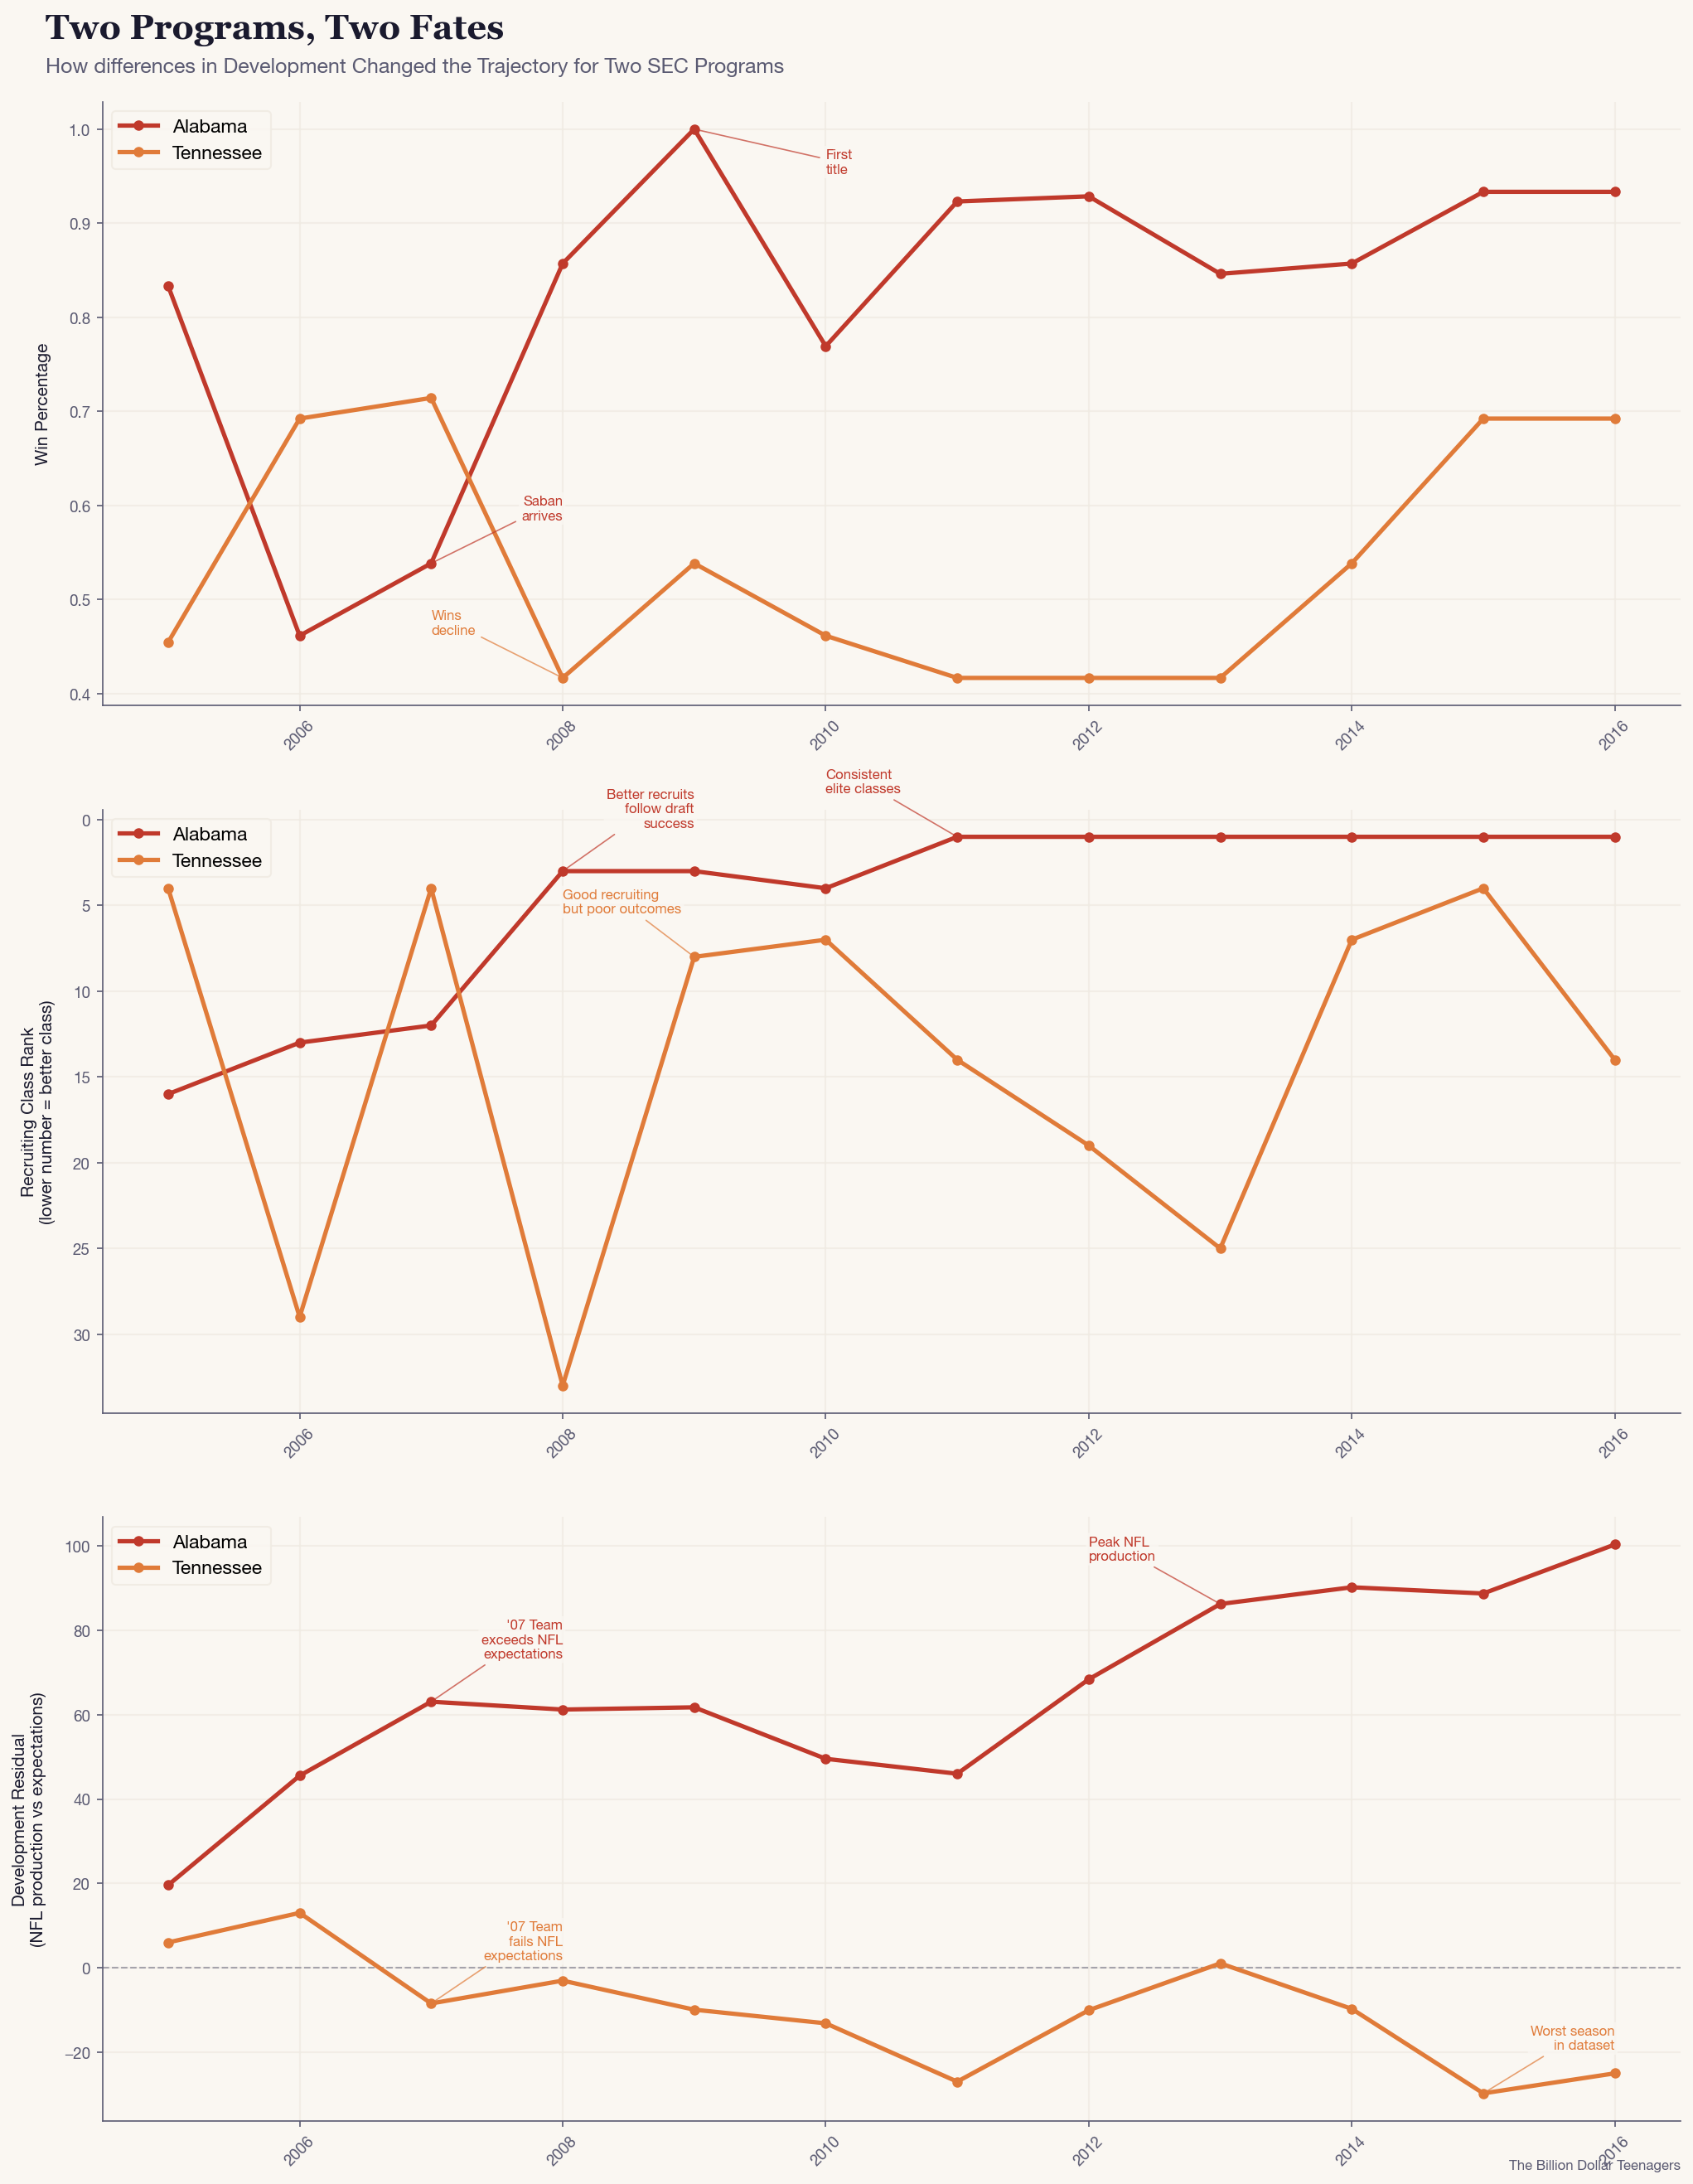

In [110]:

from theme import activate_all, NAVY, GOLD, RED, GREEN, TEXT_PRIMARY, TEXT_SECONDARY, BACKGROUND, add_signature

activate_all()

team_colors = {
    "Alabama":   "#C0392B",
    "Tennessee": "#E07B39",
}

# annotations per metric per team
annotations = {
    "Alabama": {
        "win_pct": [
            (2007, "Saban\narrives", "right"),
            (2009, "First\ntitle",   "left"),
        ],
        "rec_rank": [
            (2008, "Better recruits\nfollow draft\nsuccess", "right"),
            (2011, "Consistent\nelite classes",              "left"),
        ],
        "dev_residual": [
            (2007, "'07 Team\nexceeds NFL\nexpectations", "right"),
            (2013, "Peak NFL\nproduction",                     "left"),
        ]
    },
    "Tennessee": {
        "win_pct": [
            (2008, "Wins\ndecline", "left"),
        ],
        "rec_rank": [
            (2009, "Good recruiting\nbut poor outcomes", "left"),
        ],
        "dev_residual": [
            (2007, "'07 Team\nfails NFL\nexpectations", "right"),
            (2015, "Worst season\nin dataset",               "right"),
        ]
    }
}

metrics = ["win_pct", "rec_rank", "dev_residual"]
metric_labels = [
    "Win Percentage",
    "Recruiting Class Rank\n(lower number = better class)",
    "Development Residual\n(NFL production vs expectations)"
]

fig, axes = plt.subplots(3, 1, figsize=(14, 18))
fig.patch.set_facecolor(BACKGROUND)

fig.text(0.05, 0.98, "Two Programs, Two Fates",
         fontsize=20, fontweight="bold",
         color=TEXT_PRIMARY, fontfamily="Georgia")
fig.text(0.05, 0.965,
         "How differences in Development Changed the Trajectory for Two SEC Programs",
         fontsize=12, color=TEXT_SECONDARY)

for row_idx, (metric, ylabel) in enumerate(zip(metrics, metric_labels)):
    ax = axes[row_idx]
    ax.set_facecolor(BACKGROUND)

    for team, color in team_colors.items():
        data = program_yearly[program_yearly["team"] == team].sort_values("year")

        ax.plot(data["year"], data[metric],
                color=color, linewidth=2.5,
                marker="o", markersize=5,
                zorder=3, label=team)

        # add annotations for this team and metric
        if metric in annotations[team]:
            for ann_year, ann_text, ha in annotations[team][metric]:
                if ann_year in data["year"].values:
                    actual_val = data[data["year"] == ann_year][metric].values[0]
                    
                    # get combined y range across both teams for offset
                    all_vals = program_yearly[
                        program_yearly["team"].isin(team_colors.keys())
                    ][metric]
                    y_range = all_vals.max() - all_vals.min()
                    offset = y_range * 0.08

                    # invert offset for inverted axis
                    if metric == "rec_rank":
                        offset = -offset

                    # manual override for First title
                    if ann_text == "First\ntitle":
                        xytext = (ann_year + 1, actual_val - offset)
                        ann_ha = "left"
                    else:
                        xytext = (ann_year + (1 if ha == "right" else -1),
                                  actual_val + offset)
                        ann_ha = ha

                    ax.annotate(
                        ann_text,
                        xy=(ann_year, actual_val),
                        xytext=xytext,
                        fontsize=8,
                        color=color,
                        ha=ann_ha,
                        arrowprops=dict(arrowstyle="-",
                                       color=color,
                                       lw=0.8, alpha=0.7),
                        zorder=5,
                        bbox=dict(boxstyle="round,pad=0.2",
                                 facecolor=BACKGROUND,
                                 edgecolor="none",
                                 alpha=0.8)
                    )

    # invert for recruiting rank
    if metric == "rec_rank":
        ax.invert_yaxis()

    # zero line for dev residual
    if metric == "dev_residual":
        ax.axhline(y=0, color=TEXT_SECONDARY,
                   linestyle="--", linewidth=1, alpha=0.5)

    ax.set_ylabel(ylabel, fontsize=10,
                 color=TEXT_PRIMARY, labelpad=10)
    ax.legend(fontsize=11, loc="upper left")
    ax.tick_params(axis="both", labelsize=9)
    ax.xaxis.set_tick_params(rotation=45)
    ax.set_xlim(2004.5, 2016.5)

add_signature(axes[2])
plt.tight_layout(rect=[0.02, 0.02, 1, 0.96])
plt.show()

## Linked View
Coach + Program Connection

use the lag correlations before this to establish that developmnent is more important for recruiting. use this as the introduction and evidence for the idea that the coach is the lead driver in development, and that higher developing coaches often recruit better too

In [11]:

from theme import bdt_altair_theme, NAVY, GOLD, RED, TEXT_PRIMARY, TEXT_SECONDARY, BACKGROUND

alt.themes.register("bdt", bdt_altair_theme)
alt.themes.enable("bdt")
alt.data_transformers.disable_max_rows()

master = pd.read_csv("data/master.csv")
complete = master[master["complete_window"] == True].copy()

# coach career averages for left bar chart
coach_career = (complete.groupby("coach_name")
                .agg(
                    avg_dev_residual=("development_residual", "mean"),
                    avg_win_pct=("win_pct", "mean"),
                    avg_rec_points=("rec_points", "mean"),
                    total_seasons=("year", "count"),
                    primary_school=("team", lambda x: x.value_counts().index[0])
                )
                .query("total_seasons >= 4")
                .reset_index()
                .dropna(subset=["coach_name"]))

top15 = coach_career.nlargest(15, "avg_dev_residual")
bot15 = coach_career.nsmallest(15, "avg_dev_residual")
bar_data = pd.concat([top15, bot15]).reset_index(drop=True)
bar_data["bar_color"] = bar_data["avg_dev_residual"].apply(
    lambda x: "positive" if x > 0 else "negative"
)

# coach tenure program scatter for right panel
coach_school = (complete.groupby(["coach_name", "team"])
                .agg(
                    avg_dev_residual=("development_residual", "mean"),
                    avg_rec_points=("rec_points", "mean"),
                    avg_win_pct=("win_pct", "mean"),
                    seasons=("year", "count"),
                    year_start=("year", "min"),
                    year_end=("year", "max"),
                )
                .reset_index()
                .dropna(subset=["coach_name"]))

valid_coaches = bar_data["coach_name"].unique()
scatter_data = coach_school[
    coach_school["coach_name"].isin(valid_coaches)
].copy()

scatter_data = scatter_data.merge(
    bar_data[["coach_name", "bar_color"]],
    on="coach_name", how="left"
)

scatter_data["tenure"] = (scatter_data["year_start"].astype(str) +
                           "–" +
                           scatter_data["year_end"].astype(str))

# altair linked view
selection = alt.selection_single(fields=["coach_name"], name="CoachSelect")

# left panel: coach bar chart
bar_color = alt.condition(
    selection,
    alt.Color("bar_color:N",
              scale=alt.Scale(domain=["positive", "negative"],
                              range=[GOLD, RED]),
              legend=None),
    alt.value("#E8E0D5")
)

bars = (alt.Chart(bar_data)
        .mark_bar()
        .encode(
            x=alt.X("avg_dev_residual:Q",
                    title="Avg Development Residual",
                    axis=alt.Axis(labelFontSize=10)),
            y=alt.Y("coach_name:N",
                    sort=alt.EncodingSortField(
                        field="avg_dev_residual", order="descending"),
                    title=None,
                    axis=alt.Axis(labelFontSize=10)),
            color=bar_color,
            tooltip=[
                alt.Tooltip("coach_name:N", title="Coach"),
                alt.Tooltip("primary_school:N", title="Primary School"),
                alt.Tooltip("avg_dev_residual:Q", title="Avg Dev Residual", format=".1f"),
                alt.Tooltip("avg_win_pct:Q", title="Avg Win %", format=".3f"),
                alt.Tooltip("total_seasons:Q", title="Total Seasons"),
            ]
        )
        .add_selection(selection)
        .properties(
            width=350,
            height=600,
            title=alt.TitleParams(
                "Who Develops NFL Talent?",
                fontSize=14,
                fontWeight="bold",
                font="Georgia"
            )
        ))

zero_line = (alt.Chart(pd.DataFrame({"x": [0]}))
             .mark_rule(color=TEXT_PRIMARY, strokeWidth=0.8, opacity=0.5)
             .encode(x="x:Q"))

bar_panel = bars + zero_line

# right panel: recruiting vs win percentage
scatter_color = alt.condition(
    selection,
    alt.Color("bar_color:N",
              scale=alt.Scale(domain=["positive", "negative"],
                              range=[GOLD, RED]),
              legend=None),
    alt.value("#E8E0D5")
)

scatter_size = alt.condition(
    selection,
    alt.value(120),
    alt.value(40)
)

scatter_opacity = alt.condition(
    selection,
    alt.value(0.9),
    alt.value(0.2)
)

scatter = (alt.Chart(scatter_data)
           .mark_circle()
           .encode(
               x=alt.X("avg_rec_points:Q",
                       title="Avg Recruiting Points",
                       axis=alt.Axis(labelFontSize=10)),
               y=alt.Y("avg_win_pct:Q",
                       title="Avg Win Percentage",
                       axis=alt.Axis(labelFontSize=10)),
               color=scatter_color,
               size=scatter_size,
               opacity=scatter_opacity,
               tooltip=[
                   alt.Tooltip("coach_name:N", title="Coach"),
                   alt.Tooltip("team:N", title="School"),
                   alt.Tooltip("tenure:N", title="Tenure"),
                   alt.Tooltip("avg_dev_residual:Q", title="Dev Residual", format=".1f"),
                   alt.Tooltip("avg_rec_points:Q", title="Avg Recruiting", format=".1f"),
                   alt.Tooltip("avg_win_pct:Q", title="Win %", format=".3f"),
                   alt.Tooltip("seasons:Q", title="Seasons"),
               ]
           )
           .properties(
               width=450,
               height=600,
               title=alt.TitleParams(
                   "Coach Tenure: Recruiting vs Winning",
                   fontSize=14,
                   fontWeight="bold",
                   font="Georgia"
               )
           ))

# reference lines
hline = (alt.Chart(pd.DataFrame({"y": [scatter_data["avg_win_pct"].median()]}))
         .mark_rule(color=TEXT_SECONDARY, strokeDash=[4, 4], opacity=0.4)
         .encode(y="y:Q"))

vline = (alt.Chart(pd.DataFrame({"x": [scatter_data["avg_rec_points"].median()]}))
         .mark_rule(color=TEXT_SECONDARY, strokeDash=[4, 4], opacity=0.4)
         .encode(x="x:Q"))

scatter_panel = scatter + hline + vline

# combine panels
chart = (alt.hconcat(bar_panel, scatter_panel)
         .properties(
             title=alt.TitleParams(
                 "Coaches with Stronger Development Ablities Win More, Across All Recruiting Levels",
                 fontSize=12,
                 color=TEXT_SECONDARY,
                 font="Helvetica Neue"
             )
         )
         .configure_view(strokeWidth=0)
         .configure_concat(spacing=30))

chart

chart.save("assets/linked_view.html")

/opt/miniconda3/lib/python3.13/site-packages/altair/utils/core.py:384: FutureWarning:

the convert_dtype parameter is deprecated and will be removed in a future version.  Do ``ser.astype(object).apply()`` instead if you want ``convert_dtype=False``.

/opt/miniconda3/lib/python3.13/site-packages/altair/utils/core.py:384: FutureWarning:

the convert_dtype parameter is deprecated and will be removed in a future version.  Do ``ser.astype(object).apply()`` instead if you want ``convert_dtype=False``.

/opt/miniconda3/lib/python3.13/site-packages/altair/utils/core.py:384: FutureWarning:

the convert_dtype parameter is deprecated and will be removed in a future version.  Do ``ser.astype(object).apply()`` instead if you want ``convert_dtype=False``.

/opt/miniconda3/lib/python3.13/site-packages/altair/utils/core.py:384: FutureWarning:

the convert_dtype parameter is deprecated and will be removed in a future version.  Do ``ser.astype(object).apply()`` instead if you want ``convert_dtype=False`

In [ ]:
html_content = """
<!DOCTYPE html>
<html lang="en">
<head>
    <meta charset="UTF-8">
    <meta name="viewport" content="width=device-width, initial-scale=1.0">
    <title>The Billion Dollar Question</title>
    <style>
        @import url('https://fonts.googleapis.com/css2?family=Playfair+Display:wght@400;700;900&family=Inter:wght@300;400;500;600&display=swap');

        * {
            margin: 0;
            padding: 0;
            box-sizing: border-box;
        }

        body {
            background-color: #FAF7F2;
            font-family: 'Inter', sans-serif;
            color: #1A1A2E;
            padding: 40px 20px;
        }

        .container {
            max-width: 900px;
            margin: 0 auto;
        }

        /* ── Header ── */
        .header {
            text-align: center;
            margin-bottom: 48px;
            border-bottom: 2px solid #1A3A5C;
            padding-bottom: 32px;
        }

        .header .eyebrow {
            font-size: 11px;
            font-weight: 600;
            letter-spacing: 3px;
            text-transform: uppercase;
            color: #C9A84C;
            margin-bottom: 12px;
        }

        .header h1 {
            font-family: 'Playfair Display', Georgia, serif;
            font-size: 48px;
            font-weight: 900;
            color: #1A1A2E;
            line-height: 1.1;
            margin-bottom: 16px;
        }

        .header h1 span {
            color: #C9A84C;
        }

        .header .subtitle {
            font-size: 16px;
            color: #5A5A72;
            max-width: 600px;
            margin: 0 auto;
            line-height: 1.6;
        }

        /* ── Hero stat ── */
        .hero {
            background: #1A3A5C;
            border-radius: 12px;
            padding: 40px;
            text-align: center;
            margin-bottom: 40px;
            position: relative;
            overflow: hidden;
        }

        .hero::before {
            content: '';
            position: absolute;
            top: -50%;
            left: -50%;
            width: 200%;
            height: 200%;
            background: radial-gradient(circle, rgba(201,168,76,0.08) 0%, transparent 60%);
        }

        .hero .label {
            font-size: 11px;
            font-weight: 600;
            letter-spacing: 3px;
            text-transform: uppercase;
            color: #C9A84C;
            margin-bottom: 16px;
        }

        .hero .number {
            font-family: 'Playfair Display', Georgia, serif;
            font-size: 88px;
            font-weight: 900;
            color: #C9A84C;
            line-height: 1;
            margin-bottom: 16px;
        }

        .hero .description {
            font-size: 20px;
            color: #FAF7F2;
            max-width: 600px;
            margin: 0 auto;
            line-height: 1.5;
            font-weight: 300;
        }

        .hero .description strong {
            color: #C9A84C;
            font-weight: 600;
        }

        /* ── Three findings ── */
        .findings {
            display: grid;
            grid-template-columns: repeat(3, 1fr);
            gap: 20px;
            margin-bottom: 40px;
        }

        .finding {
            background: #F0EBE3;
            border-radius: 10px;
            padding: 28px 24px;
            border-top: 4px solid #C9A84C;
        }

        .finding .number {
            font-family: 'Playfair Display', Georgia, serif;
            font-size: 42px;
            font-weight: 700;
            color: #1A3A5C;
            line-height: 1;
            margin-bottom: 8px;
        }

        .finding .number.red {
            color: #C0392B;
        }

        .finding .finding-title {
            font-size: 13px;
            font-weight: 600;
            color: #1A1A2E;
            margin-bottom: 8px;
            text-transform: uppercase;
            letter-spacing: 1px;
        }

        .finding .finding-desc {
            font-size: 13px;
            color: #5A5A72;
            line-height: 1.5;
        }

        /* ── Causal chain ── */
        .chain-section {
            margin-bottom: 40px;
        }

        .chain-title {
            font-family: 'Playfair Display', Georgia, serif;
            font-size: 22px;
            font-weight: 700;
            color: #1A1A2E;
            margin-bottom: 24px;
            text-align: center;
        }

        .chain {
            display: flex;
            align-items: center;
            justify-content: center;
            gap: 0;
            flex-wrap: nowrap;
        }

        .chain-node {
            background: #1A3A5C;
            border-radius: 10px;
            padding: 20px 16px;
            text-align: center;
            flex: 1;
            min-width: 0;
        }

        .chain-node .icon {
            font-size: 28px;
            margin-bottom: 8px;
        }

        .chain-node .node-title {
            font-size: 13px;
            font-weight: 600;
            color: #C9A84C;
            margin-bottom: 4px;
            text-transform: uppercase;
            letter-spacing: 0.5px;
        }

        .chain-node .node-desc {
            font-size: 11px;
            color: #FAF7F2;
            line-height: 1.4;
            opacity: 0.8;
        }

        .chain-arrow {
            display: flex;
            flex-direction: column;
            align-items: center;
            padding: 0 8px;
            flex-shrink: 0;
        }

        .chain-arrow .arrow-line {
            width: 40px;
            height: 2px;
            background: #C9A84C;
            position: relative;
        }

        .chain-arrow .arrow-line::after {
            content: '▶';
            position: absolute;
            right: -8px;
            top: -8px;
            font-size: 10px;
            color: #C9A84C;
        }

        .chain-arrow .corr {
            font-size: 10px;
            color: #C9A84C;
            margin-top: 4px;
            font-weight: 600;
        }

        /* ── Program callouts ── */
        .callouts {
            display: grid;
            grid-template-columns: repeat(2, 1fr);
            gap: 16px;
            margin-bottom: 40px;
        }

        .callout {
            background: #F0EBE3;
            border-radius: 10px;
            padding: 20px 24px;
            display: flex;
            align-items: center;
            gap: 16px;
        }

        .callout.positive {
            border-left: 4px solid #C9A84C;
        }

        .callout.negative {
            border-left: 4px solid #C0392B;
        }

        .callout .callout-stat {
            font-family: 'Playfair Display', Georgia, serif;
            font-size: 36px;
            font-weight: 700;
            flex-shrink: 0;
        }

        .callout.positive .callout-stat {
            color: #C9A84C;
        }

        .callout.negative .callout-stat {
            color: #C0392B;
        }

        .callout .callout-text .name {
            font-size: 14px;
            font-weight: 600;
            color: #1A1A2E;
            margin-bottom: 4px;
        }

        .callout .callout-text .desc {
            font-size: 12px;
            color: #5A5A72;
            line-height: 1.4;
        }

        /* ── Footer ── */
        .footer {
            text-align: center;
            padding-top: 24px;
            border-top: 1px solid #E0D8CE;
        }

        .footer p {
            font-size: 11px;
            color: #9B9B9B;
            font-style: italic;
        }
    </style>
</head>
<body>
    <div class="container">

        <!-- Header -->
        <div class="header">
            <div class="eyebrow">The Billion Dollar Teenagers</div>
            <h1>The <span>Billion Dollar</span> Question</h1>
            <p class="subtitle">
                College football spends millions recruiting the best high school talent. 
                But what actually predicts whether a program wins both now and in the future?
            </p>
        </div>

        <!-- Hero stat -->
        <div class="hero">
            <div class="label">The Punchline</div>
            <div class="number">8×</div>
            <div class="description">
                <strong>Draft production</strong> predicts future winning 
                <strong>8 times more strongly</strong> than recruiting does.
                The programs investing in development aren't just building better players;
                they're building tomorrow's wins.
            </div>
        </div>

        <!-- Three findings -->
        <div class="findings">
            <div class="finding">
                <div class="number">r = 0.04</div>
                <div class="finding-title">Recruiting → Future Wins</div>
                <div class="finding-desc">
                    Recruiting rank predicts almost nothing about winning 
                    2 years from now. The players haven't developed yet.
                </div>
            </div>
            <div class="finding">
                <div class="number">r = 0.33</div>
                <div class="finding-title">Draft Production → Future Wins</div>
                <div class="finding-desc">
                    Programs that develop NFL talent today have the 
                    pipelines and coaching that produce wins 2-3 years from now.
                </div>
            </div>
            <div class="finding">
                <div class="number red">50%</div>
                <div class="finding-title">Variance Unexplained</div>
                <div class="finding-desc">
                    Recruiting explains only 50% of NFL draft production. 
                    The other half is pure development. It's about what coaches do 
                    with the talent they have.
                </div>
            </div>
        </div>

        <!-- Causal chain -->
        <div class="chain-section">
            <div class="chain-title">The Dynasty Blueprint</div>
            <div class="chain">
                <div class="chain-node">
                    <div class="icon">🏈</div>
                    <div class="node-title">Develop Players</div>
                    <div class="node-desc">Produce NFL talent beyond recruiting expectations</div>
                </div>
                <div class="chain-arrow">
                    <div class="arrow-line"></div>
                    <div class="corr">r = 0.33</div>
                </div>
                <div class="chain-node">
                    <div class="icon">🏆</div>
                    <div class="node-title">Win Games</div>
                    <div class="node-desc">Future wins follow development 2–3 years later</div>
                </div>
                <div class="chain-arrow">
                    <div class="arrow-line"></div>
                    <div class="corr">r = 0.13</div>
                </div>
                <div class="chain-node">
                    <div class="icon">⭐</div>
                    <div class="node-title">Attract Recruits</div>
                    <div class="node-desc">Winning programs draw better recruiting classes</div>
                </div>
                <div class="chain-arrow">
                    <div class="arrow-line"></div>
                    <div class="corr">cycle</div>
                </div>
                <div class="chain-node">
                    <div class="icon">🔄</div>
                    <div class="node-title">Repeat</div>
                    <div class="node-desc">Programs that develop sustain success over time</div>
                </div>
            </div>
        </div>

        <!-- Program callouts -->
        <div class="callouts">
            <div class="callout positive">
                <div class="callout-stat">+71</div>
                <div class="callout-text">
                    <div class="name">Nick Saban · Alabama</div>
                    <div class="desc">
                        The greatest developer in FBS history. Alabama produces 
                        71 more weighted draft points per year than their 
                        recruiting rank predicts.
                    </div>
                </div>
            </div>
            <div class="callout positive">
                <div class="callout-stat">+14</div>
                <div class="callout-text">
                    <div class="name">Kirk Ferentz · Iowa</div>
                    <div class="desc">
                        The most efficient developer. Iowa consistently punches 
                        above its recruiting weight. They are proof that development 
                        matters more than star ratings.
                    </div>
                </div>
            </div>
            <div class="callout negative">
                <div class="callout-stat">−13</div>
                <div class="callout-text">
                    <div class="name">Butch Jones · Tennessee</div>
                    <div class="desc">
                        Top recruiting classes, consistently negative development. 
                        Tennessee's decline under Jones is the clearest example 
                        of talent wasted.
                    </div>
                </div>
            </div>
            <div class="callout negative">
                <div class="callout-stat">−17</div>
                <div class="callout-text">
                    <div class="name">Tim Brewster · Minnesota</div>
                    <div class="desc">
                        The worst developer in the dataset. Recruited adequately, 
                        won just 33% of games, and produced almost no NFL talent 
                        relative to expectations.
                    </div>
                </div>
            </div>
        </div>

        <!-- Footer -->
        <div class="footer">
            <p>
                Analysis based on FBS programs 2005–2016 | 
                Development residual = weighted NFL draft score vs. recruiting expectation | 
                The Billion Dollar Teenagers
            </p>
        </div>

    </div>
</body>
</html>
"""

with open("infographic.html", "w") as f:
    f.write(html_content)

print("Saved infographic.html")

Saved infographic.html
